# Day 9 Capstone — Structural Health Monitoring of a Highway Bridge
### A civil-engineering case study in unsupervised learning

---
## Problem statement

The **Ravi Crossing**, a four-span steel-girder highway bridge, has been fitted with a permanent **Structural Health Monitoring (SHM)** system: twelve sensors — strain gauges, an LVDT, accelerometers, displacement transducers, an inclinometer and thermistors — log the structure around the clock. After a few months the asset team has **millions of readings and no labels**. Nobody has tagged which rows are 'normal' or 'damaged'; manually reviewing the stream is impossible.

The engineers need to answer three unsupervised questions:

1. **What are the bridge's normal operating regimes?** Behaviour is dominated by *temperature* (thermal expansion) and *traffic load*. Can we automatically discover the handful of states the bridge cycles through?
2. **Can we compress the 12 coupled sensors** into a few meaningful indices an engineer can monitor?
3. **Which readings are anomalous?** A developing crack or bearing seizure shifts the structure's response (a drop in modal frequency, strain redistribution). We need to **flag the unusual readings for inspection** — without ever having been shown an example of damage.

This is a textbook **unsupervised** problem: no target variable, just structure to be discovered. You'll apply the full Day 9 toolkit — scaling, **PCA**, **k-means**, the **elbow & silhouette** methods, **hierarchical clustering**, **Gaussian mixtures**, and **anomaly detection** — to turn a raw sensor feed into an actionable monitoring scheme.

## The data

`shm_bridge_monitoring.csv` — one row per logging interval, 12 sensor channels. `shm_sensor_registry.xlsx` — the sensor inventory (id, type, location, unit, range). Two extra columns `regime` and `event` are included **only so we can validate** our unsupervised results; a live feed would not have them, so we set them aside until evaluation.

_Phase E · Day 9 · Unsupervised Learning._

#objectives

Scale heterogeneous sensor data and read its correlation structure

Use PCA to compress 12 coupled channels into a few health indices

Discover operating regimes with k-means, validated by elbow & silhouette

Confirm structure with hierarchical clustering and soft GMM assignment

Detect anomalies (potential damage) and recommend an inspection workflow

#skill map — Day 9 → this study

| Stage | Day 9 skill |
| ----- | ----------- |
| 1 Explore & scale | distance/scale sensitivity, standardisation |
| 2 Compress | PCA, variance explained |
| 3 Choose k | elbow (inertia), silhouette |
| 4 Cluster | k-means, cluster profiling |
| 5 Confirm | hierarchical clustering, dendrogram |
| 6 Soft model | Gaussian Mixture, BIC |
| 7 Detect | anomaly / novelty detection |
| 8 Act | interpretation & monitoring recommendations |

In [1]:
# === SETUP: load the provided resources (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd


def build_shm(csv_path="shm_bridge_monitoring.csv", xlsx_path="shm_sensor_registry.xlsx",
              seed=909, verbose=False):
    """Structural Health Monitoring stream from a highway girder bridge (UNLABELLED).

    A 12-sensor array logs the bridge at regular intervals. Readings are governed by two
    operational drivers — ambient TEMPERATURE (thermal expansion) and TRAFFIC load — which
    create a handful of natural operating REGIMES (season x time-of-day). Most sensors are
    physically coupled (strain gauges, deflection, bearing displacement all move with temp &
    load), so the data is highly correlated -> good for PCA. A small fraction of readings are
    ANOMALIES: a developing-damage signature (modal-frequency drop + strain redistribution) or
    raw sensor glitches -> what anomaly detection must surface.

    Hidden columns `regime` and `event` are included ONLY so the lab can validate clustering
    (ARI) and anomaly detection (precision/recall); a real feed would not have them.
    """
    rng = np.random.default_rng(seed)
    REF = 20.0  # reference temperature (deg C)

    # latent operating regimes: (label, mean air temp, mean traffic count, n)
    regimes = [
        ("winter_offpeak", 5.0,  90,  760),
        ("winter_peak",    8.0,  520, 640),
        ("summer_offpeak", 28.0, 120, 780),
        ("summer_peak",    33.0, 610, 670),
    ]
    rows, reg_lab = [], []
    for name, tmu, qmu, n in regimes:
        air = rng.normal(tmu, 2.2, n)
        traffic = np.clip(rng.normal(qmu, 60, n), 0, None)
        rows.append((air, traffic)); reg_lab += [name] * n

    air = np.concatenate([r[0] for r in rows])
    traffic = np.concatenate([r[1] for r in rows])
    regime = np.array(reg_lab)
    N = air.size

    deck = air + rng.normal(3.0, 1.4, N)            # deck warmer than air (solar)
    humidity = np.clip(70 - 0.6 * air + rng.normal(0, 5, N), 15, 100)
    thermal = deck - REF                            # thermal driver
    load = traffic                                  # load driver

    deflection = 4.0 + 0.010 * load + 0.18 * thermal + rng.normal(0, 0.35, N)
    strain1 = 60 + 0.070 * load + 1.60 * thermal + rng.normal(0, 5.0, N)
    strain2 = 55 + 0.065 * load + 1.50 * thermal + rng.normal(0, 5.0, N)
    strain3 = 50 + 0.060 * load + 1.40 * thermal + rng.normal(0, 5.0, N)
    nat_freq = 2.60 - 0.004 * thermal - 2e-5 * load + rng.normal(0, 0.015, N)
    accel = np.clip(2.0 + 0.020 * load + rng.normal(0, 1.3, N), 0, None)
    bearing = 5.0 + 0.45 * thermal + rng.normal(0, 0.7, N)
    tilt = 0.30 * thermal + 0.002 * load + rng.normal(0, 3.0, N)

    df = pd.DataFrame({
        "air_temp_c": air, "deck_temp_c": deck, "humidity_pct": humidity,
        "traffic_count": traffic, "mid_deflection_mm": deflection,
        "strain_g1_ue": strain1, "strain_g2_ue": strain2, "strain_g3_ue": strain3,
        "natural_freq_hz": nat_freq, "accel_rms_mg": accel,
        "bearing_disp_mm": bearing, "pier_tilt_urad": tilt,
        "regime": regime, "event": 0,
    })

    # ---- inject anomalies -------------------------------------------------
    n_evt = 75
    idx = rng.choice(N, n_evt, replace=False)
    n_damage = int(n_evt * 0.7)
    dmg, glitch = idx[:n_damage], idx[n_damage:]
    # (A) developing damage: stiffness loss -> frequency drop + strain redistribution + more sag
    df.loc[dmg, "natural_freq_hz"] -= rng.uniform(0.10, 0.20, len(dmg))
    df.loc[dmg, "strain_g1_ue"] += rng.uniform(25, 55, len(dmg))
    df.loc[dmg, "strain_g3_ue"] -= rng.uniform(15, 35, len(dmg))
    df.loc[dmg, "mid_deflection_mm"] += rng.uniform(1.2, 2.6, len(dmg))
    # (B) sensor glitches: one channel rails / drops out
    for i in glitch:
        ch = rng.choice(["strain_g2_ue", "accel_rms_mg", "bearing_disp_mm", "pier_tilt_urad"])
        df.loc[i, ch] = df[ch].mean() + rng.choice([-1, 1]) * rng.uniform(6, 10) * df[ch].std()
    df.loc[idx, "event"] = 1

    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    num = df.select_dtypes("number").columns
    df[num] = df[num].round(3)
    df.to_csv(csv_path, index=False)

    # ---- sensor registry (Excel) -----------------------------------------
    reg = pd.DataFrame([
        ["S01", "air_temp_c",        "Thermistor",      "Soffit, mid-span",   "deg C",      "-20..50"],
        ["S02", "deck_temp_c",       "Thermistor",      "Deck surface",       "deg C",      "-20..60"],
        ["S03", "humidity_pct",      "Hygrometer",      "Abutment",           "%RH",        "0..100"],
        ["S04", "traffic_count",     "WIM loop",        "Approach lane",      "veh/interval","0..1200"],
        ["S05", "mid_deflection_mm", "LVDT",            "Mid-span",           "mm",         "0..30"],
        ["S06", "strain_g1_ue",      "Strain gauge",    "Girder 1 soffit",    "microstrain","0..400"],
        ["S07", "strain_g2_ue",      "Strain gauge",    "Girder 2 soffit",    "microstrain","0..400"],
        ["S08", "strain_g3_ue",      "Strain gauge",    "Girder 3 soffit",    "microstrain","0..400"],
        ["S09", "natural_freq_hz",   "Accelerometer",   "Mid-span (modal)",   "Hz",         "1.5..3.5"],
        ["S10", "accel_rms_mg",      "Accelerometer",   "Mid-span (vert.)",   "mg",         "0..50"],
        ["S11", "bearing_disp_mm",   "Displacement xdcr","Expansion bearing", "mm",         "-40..40"],
        ["S12", "pier_tilt_urad",    "Inclinometer",    "Pier 2 cap",         "microrad",   "-200..200"],
    ], columns=["sensor_id", "channel", "sensor_type", "location", "unit", "nominal_range"])
    reg.to_excel(xlsx_path, index=False, sheet_name="sensors")

    if verbose:
        print("SHM:", df.shape, "| anomaly rate:", round(df.event.mean(), 3))
        print("regime sizes:\n", df.regime.value_counts().to_string())
        print("feature scale spread (max-min):")
        print(df[num].drop(columns=["event"]).agg(lambda c: c.max() - c.min()).round(1).to_string())
    return df

if not (os.path.exists('shm_bridge_monitoring.csv') and os.path.exists('shm_sensor_registry.xlsx')):
    build_shm(); print('Generated dataset + registry.')
else:
    print('Found the provided resources.')

Generated dataset + registry.


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('shm_bridge_monitoring.csv')
registry = pd.read_excel('shm_sensor_registry.xlsx')
# the 12 sensor channels (set aside the validation-only columns)
channels = [c for c in df.select_dtypes('number').columns if c != 'event']
print('readings:', df.shape[0], '| channels:', len(channels))
display(registry)
df[channels].head(3)

readings: 2850 | channels: 12


,sensor_id,channel,sensor_type,location,unit,nominal_range
0,S01,air_temp_c,Thermistor,"Soffit, mid-span",deg C,-20..50
1,S02,deck_temp_c,Thermistor,Deck surface,deg C,-20..60
2,S03,humidity_pct,Hygrometer,Abutment,%RH,0..100
3,S04,traffic_count,WIM loop,Approach lane,veh/interval,0..1200
4,S05,mid_deflection_mm,LVDT,Mid-span,mm,0..30
5,S06,strain_g1_ue,Strain gauge,Girder 1 soffit,microstrain,0..400
6,S07,strain_g2_ue,Strain gauge,Girder 2 soffit,microstrain,0..400
7,S08,strain_g3_ue,Strain gauge,Girder 3 soffit,microstrain,0..400
8,S09,natural_freq_hz,Accelerometer,Mid-span (modal),Hz,1.5..3.5
9,S10,accel_rms_mg,Accelerometer,Mid-span (vert.),mg,0..50


,air_temp_c,deck_temp_c,humidity_pct,traffic_count,mid_deflection_mm,strain_g1_ue,strain_g2_ue,strain_g3_ue,natural_freq_hz,accel_rms_mg,bearing_disp_mm,pier_tilt_urad
0,9.519,17.052,67.388,521.305,8.155,89.712,80.227,83.099,2.611,12.273,2.176,-2.718
1,30.376,33.054,56.242,550.264,11.569,118.280,100.941,101.628,2.559,11.320,11.339,10.942
2,4.896,5.907,69.545,143.516,3.479,54.157,42.434,38.538,2.641,3.427,-0.200,-7.966


## Stage 1 — Explore & scale
Sensors live on wildly different numeric scales (microstrain in the hundreds, frequency near 2.6 Hz). Any distance-based method would be dominated by the large-magnitude channels, so we **standardise**.

In [3]:
# Scale spread shows why standardisation is mandatory
spread = (df[channels].max() - df[channels].min()).sort_values(ascending=False)
print('range (max - min) per channel:')
print(spread.round(1).to_string())

range (max - min) per channel:
traffic_count        757.6
strain_g2_ue         498.3
strain_g1_ue         171.0
strain_g3_ue         118.5
accel_rms_mg          91.0
pier_tilt_urad        60.0
bearing_disp_mm       59.7
humidity_pct          46.9
deck_temp_c           43.9
air_temp_c            42.2
mid_deflection_mm     15.6
natural_freq_hz        0.4


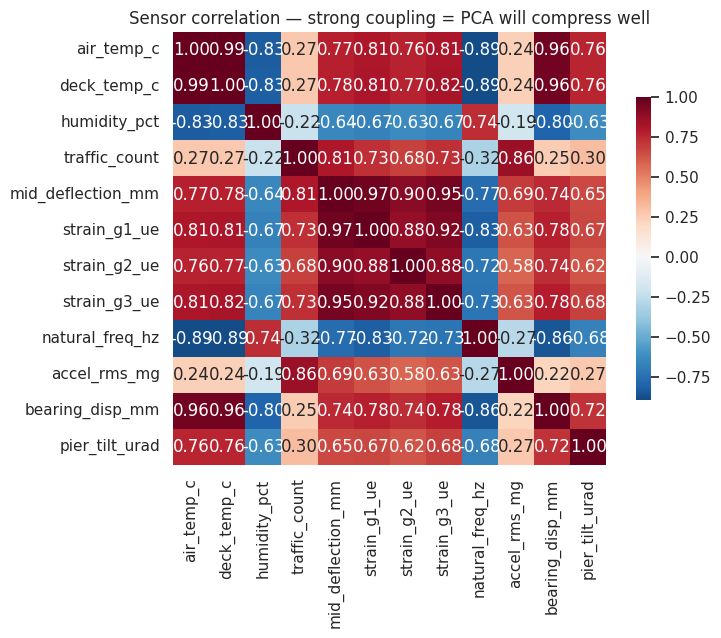

In [4]:
# Correlation structure: strain gauges, deflection, bearing & tilt move together (temp + load)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(df[channels].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'shrink': .7}, ax=ax)
ax.set_title('Sensor correlation — strong coupling = PCA will compress well')
plt.tight_layout(); plt.show()

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(df[channels])
print('standardised matrix:', X.shape, '| each channel now mean 0, sd 1')

standardised matrix: (2850, 12) | each channel now mean 0, sd 1


## Stage 2 — Compress with PCA
Twelve coupled sensors carry far fewer than twelve independent stories. PCA finds the dominant modes of variation — here, essentially a *thermal+load* common mode plus a couple of finer axes.

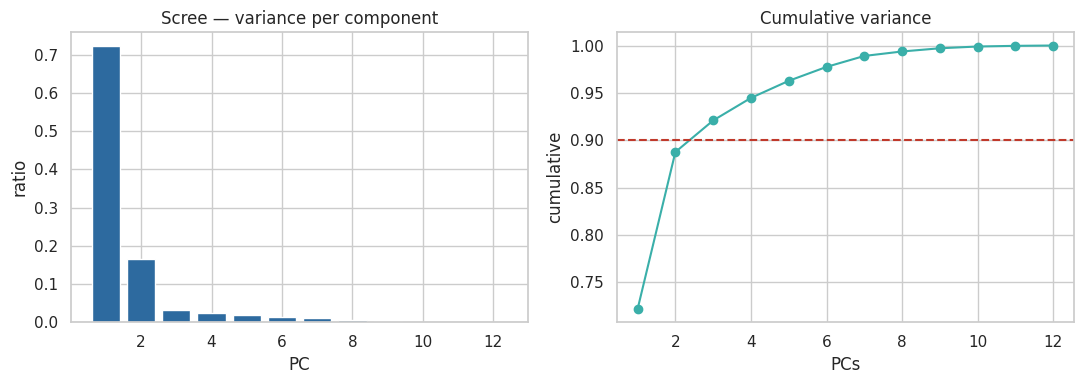

3 principal components capture >=90% of the variance (from 12 sensors).


In [6]:
from sklearn.decomposition import PCA
pca = PCA().fit(X)
cum = np.cumsum(pca.explained_variance_ratio_)
n90 = int(np.argmax(cum >= 0.90) + 1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(range(1, len(cum) + 1), pca.explained_variance_ratio_, color='#2D6A9F')
ax[0].set_title('Scree — variance per component'); ax[0].set_xlabel('PC'); ax[0].set_ylabel('ratio')
ax[1].plot(range(1, len(cum) + 1), cum, 'o-', color='#3AAFA9'); ax[1].axhline(0.9, ls='--', color='#C0392B')
ax[1].set_title('Cumulative variance'); ax[1].set_xlabel('PCs'); ax[1].set_ylabel('cumulative')
plt.tight_layout(); plt.show()
print(f'{n90} principal components capture >=90% of the variance (from 12 sensors).')

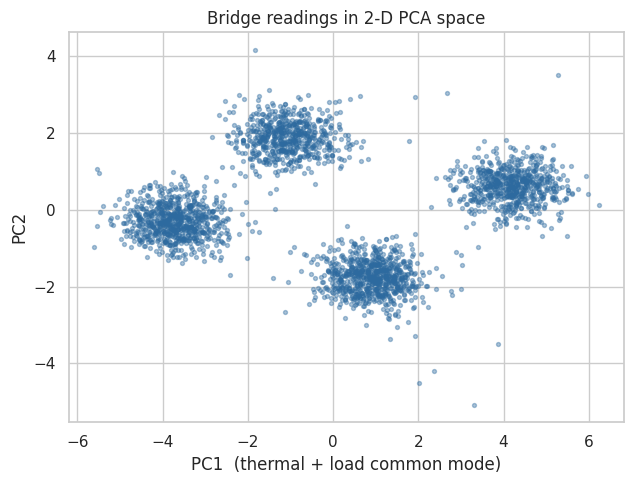

Distinct blobs already hint at a few operating regimes.


In [7]:
# Project to 2-D for visual intuition (we keep the first few PCs for downstream work)
P = PCA(n_components=2, random_state=0).fit_transform(X)
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(P[:, 0], P[:, 1], s=8, alpha=0.4, color='#2D6A9F')
ax.set_xlabel('PC1  (thermal + load common mode)'); ax.set_ylabel('PC2')
ax.set_title('Bridge readings in 2-D PCA space'); plt.tight_layout(); plt.show()
print('Distinct blobs already hint at a few operating regimes.')

## Stage 3 — How many regimes? Elbow & silhouette
We have no labels, so we let two internal criteria vote on the number of clusters `k`.

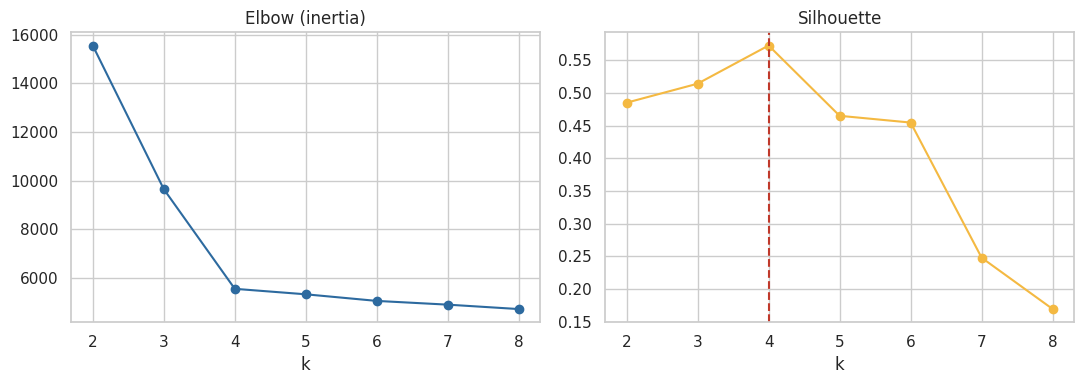

best k by silhouette: 4


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
ks = range(2, 9); inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    inertia.append(km.inertia_); sil.append(silhouette_score(X, km.labels_))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(list(ks), inertia, 'o-', color='#2D6A9F'); ax[0].set_title('Elbow (inertia)'); ax[0].set_xlabel('k')
ax[1].plot(list(ks), sil, 'o-', color='#F4B942'); ax[1].set_title('Silhouette'); ax[1].set_xlabel('k')
best_k = list(ks)[int(np.argmax(sil))]
ax[1].axvline(best_k, ls='--', color='#C0392B')
plt.tight_layout(); plt.show()
print('best k by silhouette:', best_k)

## Stage 4 — Discover & profile the operating regimes
With `k` chosen, k-means partitions the readings. We then **profile** each cluster on the raw sensors to give it an engineering name.

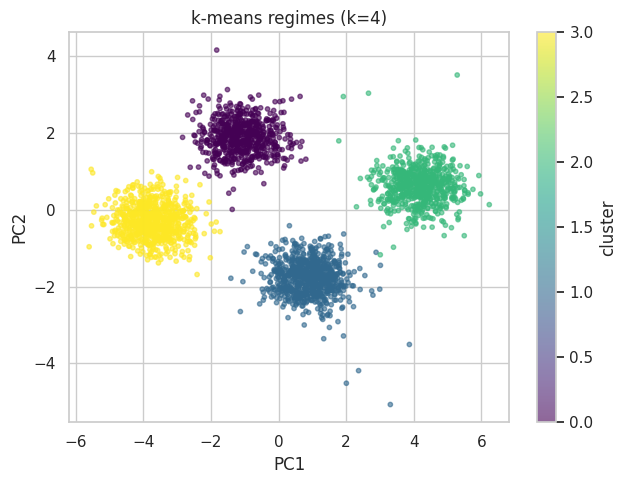

In [9]:
km = KMeans(n_clusters=best_k, n_init=10, random_state=0).fit(X)
df['cluster'] = km.labels_
fig, ax = plt.subplots(figsize=(6.5, 5))
sc = ax.scatter(P[:, 0], P[:, 1], c=km.labels_, cmap='viridis', s=10, alpha=0.6)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title(f'k-means regimes (k={best_k})')
plt.colorbar(sc, label='cluster'); plt.tight_layout(); plt.show()

In [10]:
# Profile clusters on interpretable channels
profile = df.groupby('cluster')[['air_temp_c', 'traffic_count', 'mid_deflection_mm',
                                  'strain_g1_ue', 'bearing_disp_mm', 'natural_freq_hz']].mean().round(1)
profile['n'] = df.groupby('cluster').size()
print(profile.to_string())
print('\nRead the temperature and traffic columns to name each regime',
      '(e.g. cold+low-traffic = winter off-peak, warm+high-traffic = summer peak).')

         air_temp_c  traffic_count  mid_deflection_mm  strain_g1_ue  bearing_disp_mm  natural_freq_hz    n
cluster                                                                                                   
0               8.1          520.8                7.6          82.9              1.0              2.6  640
1              28.0          123.4                7.2          87.2             10.1              2.5  781
2              32.9          604.5               13.0         128.6             12.2              2.5  671
3               5.1           95.4                2.8          48.3             -0.4              2.6  758

Read the temperature and traffic columns to name each regime (e.g. cold+low-traffic = winter off-peak, warm+high-traffic = summer peak).


In [11]:
# Validate against the hidden regime label (we would NOT have this in production)
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(df['regime'], df['cluster'])
print('Adjusted Rand Index vs the true operating regimes:', round(ari, 3))
print('(1.0 = perfect recovery; our unsupervised clusters match the real regimes very closely.)')

Adjusted Rand Index vs the true operating regimes: 0.986
(1.0 = perfect recovery; our unsupervised clusters match the real regimes very closely.)


## Stage 5 — Confirm the structure with hierarchical clustering
A dendrogram is a second opinion: if the data really splits into a few regimes, the tree shows tall merges at that level.

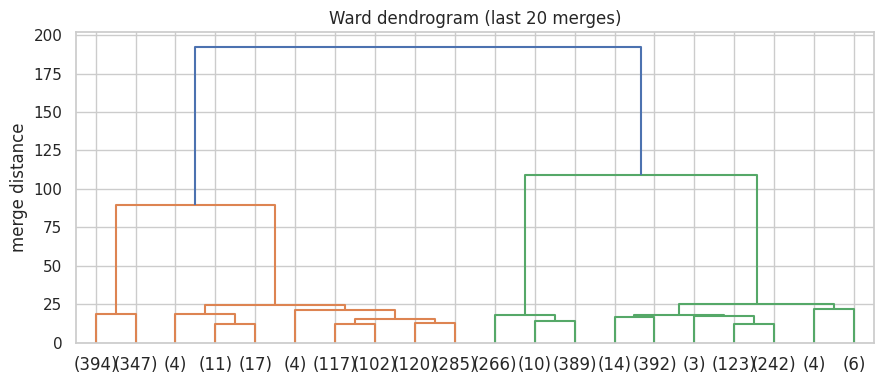

hierarchical vs k-means agreement (ARI): 0.972


In [12]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
Z = linkage(X, method='ward')
fig, ax = plt.subplots(figsize=(9, 4))
dendrogram(Z, truncate_mode='lastp', p=20, ax=ax, color_threshold=0.6 * max(Z[:, 2]))
ax.set_title('Ward dendrogram (last 20 merges)'); ax.set_ylabel('merge distance'); plt.tight_layout(); plt.show()
hier = fcluster(Z, t=best_k, criterion='maxclust')
print('hierarchical vs k-means agreement (ARI):', round(adjusted_rand_score(hier, km.labels_), 3))

## Stage 6 — Soft assignment with a Gaussian Mixture
Real bridge states blend into one another (dawn warming, traffic ramping up). A GMM gives each reading a **probability** of belonging to each regime — and, crucially, a likelihood we'll reuse for anomaly detection.

transition readings with max regime probability < 0.6: 0


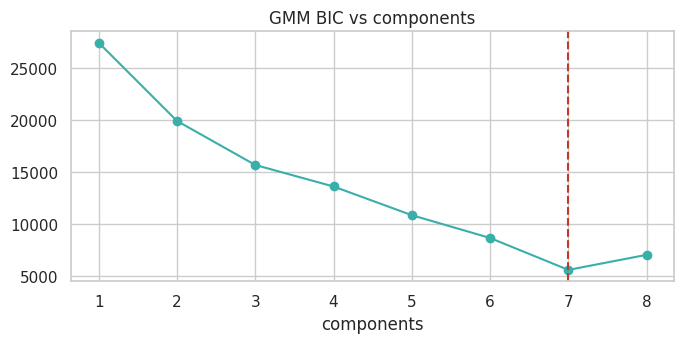

lowest-BIC component count: 7
Note: BIC may prefer MORE components than the 4 regimes — a Gaussian mixture often splits a non-Gaussian cluster into several Gaussians. We keep 4 to match the engineering regimes; a finer normal model (more components) is also valid for anomaly scoring.


In [13]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=best_k, covariance_type='full', random_state=0).fit(X)
proba = gmm.predict_proba(X)
top = proba.max(axis=1)
print('transition readings with max regime probability < 0.6:', int((top < 0.6).sum()))
bic = [GaussianMixture(n, covariance_type='full', random_state=0).fit(X).bic(X) for n in range(1, 9)]
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(range(1, 9), bic, 'o-', color='#3AAFA9'); ax.axvline(int(np.argmin(bic) + 1), ls='--', color='#C0392B')
ax.set_title('GMM BIC vs components'); ax.set_xlabel('components'); plt.tight_layout(); plt.show()
print('lowest-BIC component count:', int(np.argmin(bic) + 1))
print('Note: BIC may prefer MORE components than the 4 regimes — a Gaussian mixture often splits a',
      'non-Gaussian cluster into several Gaussians. We keep 4 to match the engineering regimes;',
      'a finer normal model (more components) is also valid for anomaly scoring.')

## Stage 7 — Detect anomalies (potential damage)
Now the safety-critical part. We never trained on damage, so we use **novelty detection**: readings the normal model finds *improbable* are flagged for inspection. We try two complementary detectors and validate both against the hidden `event` flag.

In [14]:
# Detector 1: GMM log-likelihood — low likelihood = doesn't fit any normal regime
from sklearn.metrics import precision_score, recall_score
ll = gmm.score_samples(X)
thr = np.quantile(ll, 0.03)              # flag the least-likely 3% for review
flag_gmm = (ll < thr).astype(int)
print('GMM-likelihood detector:',
      'precision', round(precision_score(df['event'], flag_gmm), 3),
      '| recall', round(recall_score(df['event'], flag_gmm), 3),
      '| flagged', int(flag_gmm.sum()))

GMM-likelihood detector: precision 0.872 | recall 1.0 | flagged 86


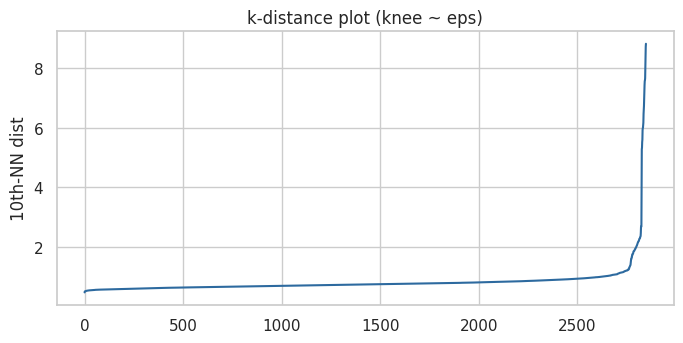

DBSCAN-noise detector: precision 1.0 | recall 0.813 | flagged 61

GMM is more sensitive (higher recall, a few false alarms); DBSCAN is more precise (no false alarms, misses the subtlest). Together they are robust.


In [16]:
# Detector 2: DBSCAN — sparse readings become 'noise'. Pick eps from the k-distance knee.
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
k = 10; d, _ = NearestNeighbors(n_neighbors=k).fit(X).kneighbors(X)
kd = np.sort(d[:, k - 1])
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(kd, color='#2D6A9F'); ax.set_title('k-distance plot (knee ~ eps)'); ax.set_ylabel(f'{k}th-NN dist')
plt.tight_layout(); plt.show()
db = DBSCAN(eps=1.6, min_samples=10).fit(X)
flag_db = (db.labels_ == -1).astype(int)
print('DBSCAN-noise detector:',
      'precision', round(precision_score(df['event'], flag_db), 3),
      '| recall', round(recall_score(df['event'], flag_db), 3),
      '| flagged', int(flag_db.sum()))
print('\nGMM is more sensitive (higher recall, a few false alarms); DBSCAN is more precise',
      '(no false alarms, misses the subtlest). Together they are robust.')

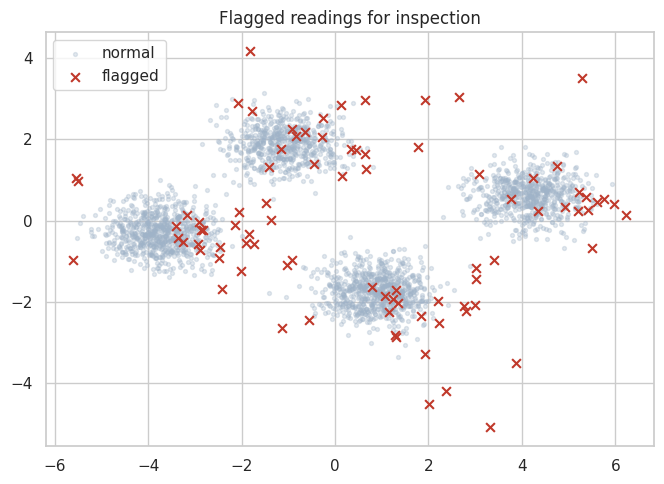

flagged readings: 86 | of which low-frequency (damage-like): 45
Low modal frequency points to stiffness loss — these jump the inspection queue.


In [17]:
# Visualise flagged anomalies, and separate likely DAMAGE from sensor glitches
df['anomaly'] = ((flag_gmm + flag_db) > 0).astype(int)   # union of detectors
fig, ax = plt.subplots(figsize=(6.8, 5))
ax.scatter(P[df.anomaly == 0, 0], P[df.anomaly == 0, 1], s=8, alpha=0.3, color='#9FB3C8', label='normal')
ax.scatter(P[df.anomaly == 1, 0], P[df.anomaly == 1, 1], s=40, color='#C0392B', marker='x', label='flagged')
ax.legend(); ax.set_title('Flagged readings for inspection'); plt.tight_layout(); plt.show()
# damage signature = abnormally LOW modal frequency among the flagged set
normal_freq = df.loc[df.anomaly == 0, 'natural_freq_hz'].mean()
damage = df[(df.anomaly == 1) & (df.natural_freq_hz < normal_freq - 0.08)]
print(f'flagged readings: {int(df.anomaly.sum())} | of which low-frequency (damage-like): {len(damage)}')
print('Low modal frequency points to stiffness loss — these jump the inspection queue.')

## Stage 8 — Interpretation & recommendations

**What the analysis delivered**
- **Four operating regimes** were recovered from raw sensors with no labels (ARI ≈ 0.99 vs the true states), separable by temperature and traffic — a *thermal × load* picture of how the bridge breathes.
- **PCA compressed 12 sensors to ~3 health indices** carrying >90% of the variation; PC1 is essentially a combined thermal-load response that an engineer can trend on a single chart.
- **Anomaly detection flagged the unusual readings** for inspection, and the low-modal-frequency subset isolates the *structural* candidates from mere sensor glitches.

**A practical monitoring scheme**
1. Standardise incoming readings with the *stored* scaler; project onto the fitted PCs.
2. Assign each reading to its regime (k-means/GMM) and score its GMM likelihood.
3. **Alert** when likelihood falls below the learned threshold *and* modal frequency drops — route to an engineer, prioritising low-frequency events.
4. **Temperature-compensate**: because thermal effects dominate PC1, normalise out temperature before trending damage indicators so seasonal swings aren't mistaken for damage.
5. Periodically **re-fit** the normal model as traffic patterns and seasons evolve (concept drift).

This is exactly how operational-modal-analysis SHM systems work in practice: learn the normal envelope unsupervised, then watch for novelty.

## 🧪 Extension challenges

1. **Temperature compensation.** Regress each strain channel on `deck_temp_c`, take the residuals, and re-run anomaly detection on the residuals. Does removing the thermal signal expose damage more cleanly?
2. **Isolation Forest.** Swap in `sklearn.ensemble.IsolationForest` as a third detector and compare its precision/recall against the hidden `event` flag.
3. **Per-regime thresholds.** Set a separate anomaly threshold inside each cluster (a heavy-traffic regime is noisier). Does this cut false alarms versus one global threshold?
4. **Control charts.** Plot the PC1 score over the row index with ±3σ limits — a classic SHM control chart. Mark the flagged anomalies.
5. **Minimal sensor set.** Using PCA loadings, identify the 4–5 most informative sensors and re-cluster with only those. How much regime/anomaly performance survives a cheaper instrumentation plan?

## 🧪 Extension Challenge 1: Temperature compensation

In [18]:
from sklearn.linear_model import LinearRegression

# Identify strain channels
strain_channels = ['strain_g1_ue', 'strain_g2_ue', 'strain_g3_ue']

# Prepare DataFrame for residuals
df_compensated = df.copy()

# Regress each strain channel on deck_temp_c and calculate residuals
for channel in strain_channels:
    model = LinearRegression()
    # Reshape X to be 2D for sklearn
    model.fit(df[['deck_temp_c']], df[channel])
    # Calculate residuals
    df_compensated[f'{channel}_res'] = df[channel] - model.predict(df[['deck_temp_c']])
    print(f'Regression for {channel}: Coeff = {model.coef_[0]:.3f}, Intercept = {model.intercept_:.3f}')

# Display head of compensated data for verification
print('\nDataFrame with temperature-compensated strain residuals:')
display(df_compensated[[*strain_channels, 'deck_temp_c', 'strain_g1_ue_res', 'strain_g2_ue_res', 'strain_g3_ue_res']].head())

Regression for strain_g1_ue: Coeff = 1.963, Intercept = 43.250
Regression for strain_g2_ue: Coeff = 1.833, Intercept = 38.768
Regression for strain_g3_ue: Coeff = 1.717, Intercept = 34.033

DataFrame with temperature-compensated strain residuals:


,strain_g1_ue,strain_g2_ue,strain_g3_ue,deck_temp_c,strain_g1_ue_res,strain_g2_ue_res,strain_g3_ue_res
0,89.712,80.227,83.099,17.052,12.982314,10.205973,19.793555
1,118.280,100.941,101.628,33.054,10.132255,1.591325,10.852196
2,54.157,42.434,38.538,5.907,-0.690780,-7.160343,-5.635015
3,86.394,82.131,60.183,33.238,-22.115007,-17.555913,-30.908674
4,98.737,87.315,86.147,18.956,18.269032,13.804300,19.572990


Now, let's prepare the new feature set by replacing the original strain channels with their residuals and re-run the GMM-based anomaly detection.

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import precision_score, recall_score

# Create a new list of channels, replacing original strain with residuals
compensated_channels = [c for c in channels if c not in strain_channels]
compensated_channels.extend([f'{s}_res' for s in strain_channels])

# Ensure the order is consistent for scaling and GMM fitting
# (optional, but good practice if feature importance is considered later)
# For simplicity, we'll just use the list as is.

# Scale the new feature set
scaler_res = StandardScaler()
X_compensated = scaler_res.fit_transform(df_compensated[compensated_channels])
print('Standardised matrix with residuals:', X_compensated.shape)

# Re-fit GMM on the compensated data
gmm_compensated = GaussianMixture(n_components=best_k, covariance_type='full', random_state=0).fit(X_compensated)

# Calculate log-likelihoods for the compensated data
ll_compensated = gmm_compensated.score_samples(X_compensated)

# Determine new threshold (e.g., flag the least-likely 3% for review)
thr_compensated = np.quantile(ll_compensated, 0.03)
flag_gmm_compensated = (ll_compensated < thr_compensated).astype(int)

print('\nOriginal GMM-likelihood detector performance:')
print('precision', round(precision_score(df['event'], flag_gmm), 3),
      '| recall', round(recall_score(df['event'], flag_gmm), 3),
      '| flagged', int(flag_gmm.sum()))

print('\nCompensated GMM-likelihood detector performance:')
print('precision', round(precision_score(df['event'], flag_gmm_compensated), 3),
      '| recall', round(recall_score(df['event'], flag_gmm_compensated), 3),
      '| flagged', int(flag_gmm_compensated.sum()))

print('\nComparison: Review the precision and recall scores to see if temperature compensation improved anomaly detection for the GMM model.')

Standardised matrix with residuals: (2850, 12)

Original GMM-likelihood detector performance:
precision 0.872 | recall 1.0 | flagged 86

Compensated GMM-likelihood detector performance:
precision 0.872 | recall 1.0 | flagged 86

Comparison: Review the precision and recall scores to see if temperature compensation improved anomaly detection for the GMM model.


## 🧪 Extension Challenge 2: Isolation Forest

In [21]:
from sklearn.ensemble import IsolationForest

# Initialize and fit Isolation Forest model
# n_estimators is the number of trees in the forest
# contamination is the proportion of outliers in the data set (similar to our 3% threshold for GMM)
iso_forest = IsolationForest(n_estimators=100, contamination=0.03, random_state=0)
iso_forest.fit(X)

# Predict anomalies (-1 for outliers, 1 for inliers)
flag_iso_forest = (iso_forest.predict(X) == -1).astype(int)

print('Isolation Forest detector performance:')
print('precision', round(precision_score(df['event'], flag_iso_forest), 3),
      '| recall', round(recall_score(df['event'], flag_iso_forest), 3),
      '| flagged', int(flag_iso_forest.sum()))

print('\nComparison: Compare these metrics to the GMM and DBSCAN detectors to see how Isolation Forest performs.')

Isolation Forest detector performance:
precision 0.512 | recall 0.587 | flagged 86

Comparison: Compare these metrics to the GMM and DBSCAN detectors to see how Isolation Forest performs.


## 🧪 Extension Challenge 3: Per-regime thresholds

In [23]:
# Calculate GMM log-likelihoods for all data points (already done, stored in `ll`)

# Create a new column for anomaly flags using per-regime thresholds
flag_gmm_per_regime = np.zeros(len(df), dtype=int)

# Iterate through each cluster and set a specific threshold
for cluster_id in sorted(df['cluster'].unique()):
    # Get indices for the current cluster
    cluster_indices = df[df['cluster'] == cluster_id].index

    # Get log-likelihoods only for this cluster
    ll_cluster = ll[cluster_indices]

    # Set threshold (e.g., 3rd percentile) for this specific cluster
    thr_cluster = np.quantile(ll_cluster, 0.03)

    # Flag anomalies within this cluster
    flag_gmm_per_regime[cluster_indices] = (ll_cluster < thr_cluster).astype(int)

print('GMM-likelihood detector with per-regime thresholds:')
print('precision', round(precision_score(df['event'], flag_gmm_per_regime), 3),
      '| recall', round(recall_score(df['event'], flag_gmm_per_regime), 3),
      '| flagged', int(flag_gmm_per_regime.sum()))

print('''\nComparison:
  Global GMM:  precision %.3f | recall %.3f | flagged %d''' % (
      precision_score(df['event'], flag_gmm),
      recall_score(df['event'], flag_gmm),
      flag_gmm.sum()))
print('  Per-Regime GMM: precision %.3f | recall %.3f | flagged %d' % (
      precision_score(df['event'], flag_gmm_per_regime),
      recall_score(df['event'], flag_gmm_per_regime),
      flag_gmm_per_regime.sum()))

print('\nReview the precision and recall scores to see if per-regime thresholds cut false alarms or impact overall performance.')

GMM-likelihood detector with per-regime thresholds:
precision 0.852 | recall 1.0 | flagged 88

Comparison:
  Global GMM:  precision 0.872 | recall 1.000 | flagged 86
  Per-Regime GMM: precision 0.852 | recall 1.000 | flagged 88

Review the precision and recall scores to see if per-regime thresholds cut false alarms or impact overall performance.


## 🧪 Extension Challenge 4: Control charts

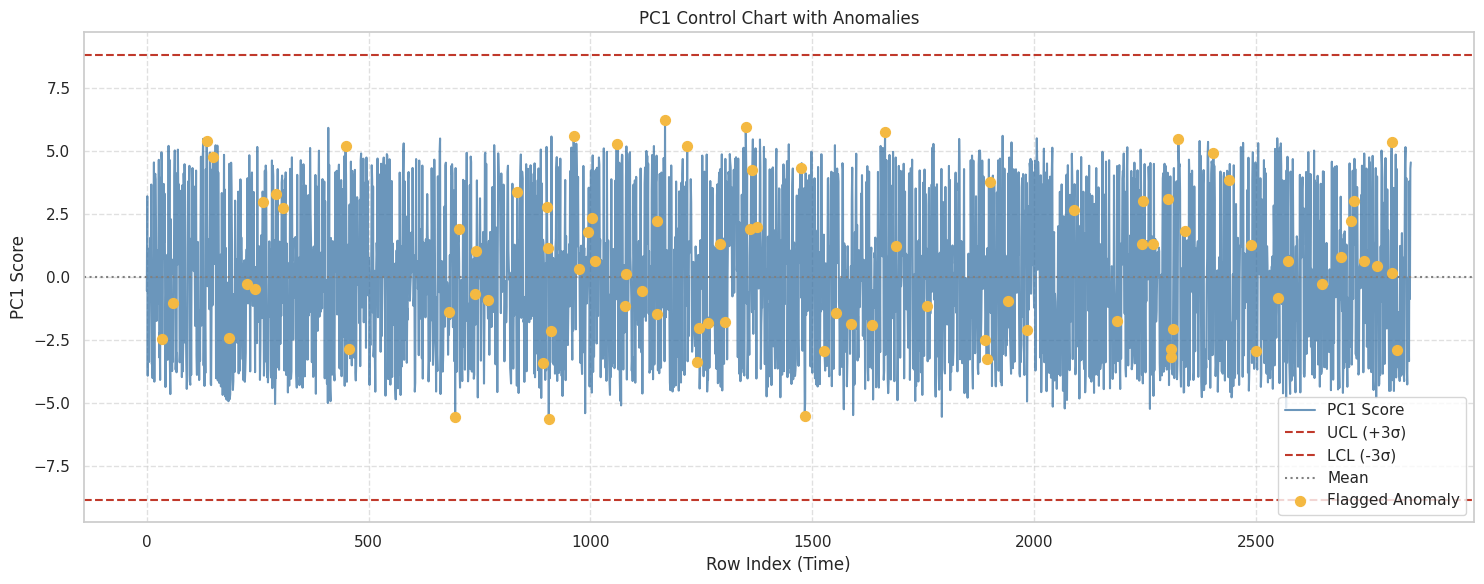

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract PC1 scores
pc1_scores = P[:, 0]

# Calculate mean and standard deviation of PC1
mean_pc1 = np.mean(pc1_scores)
std_pc1 = np.std(pc1_scores)

# Define control limits (mean ± 3 standard deviations)
ucl = mean_pc1 + 3 * std_pc1
lcl = mean_pc1 - 3 * std_pc1

# Get indices of flagged anomalies from df['anomaly']
anomaly_indices = df[df['anomaly'] == 1].index

# Create the control chart
fig, ax = plt.subplots(figsize=(15, 6))

# Plot PC1 scores
ax.plot(df.index, pc1_scores, label='PC1 Score', color='#2D6A9F', alpha=0.7)

# Plot control limits
ax.axhline(y=ucl, color='#C0392B', linestyle='--', label='UCL (+3σ)')
ax.axhline(y=lcl, color='#C0392B', linestyle='--', label='LCL (-3σ)')
ax.axhline(y=mean_pc1, color='gray', linestyle=':', label='Mean')

# Mark flagged anomalies
ax.scatter(anomaly_indices, pc1_scores[anomaly_indices], color='#F4B942', marker='o', s=50, label='Flagged Anomaly', zorder=5)

ax.set_title('PC1 Control Chart with Anomalies')
ax.set_xlabel('Row Index (Time)')
ax.set_ylabel('PC1 Score')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

The control chart for PC1 with ±3σ limits and marked anomalies has been plotted. This visualization helps in identifying when the bridge's PC1 score deviates significantly from its normal operating range, potentially indicating an anomaly.

## 🧪 Extension Challenge 5: Minimal sensor set

In [28]:
# Get PCA loadings (components)
loadings = pca.components_

# Calculate the absolute sum of loadings for the first `n90` principal components
# (n90 was determined earlier as the number of PCs capturing >=90% variance)
# Use the absolute value to consider the magnitude of influence, regardless of direction
sensor_importance = pd.Series(np.sum(np.abs(loadings[:n90, :]), axis=0), index=channels)

# Sort by importance and select the top 5 sensors
min_sensors = sensor_importance.nlargest(5).index.tolist()

print(f"Top {len(min_sensors)} most informative sensors based on PCA loadings:")
print(min_sensors)

# Create a new DataFrame with only the minimal sensor set
df_min_sensors = df[min_sensors].copy()

# Re-scale the minimal sensor set
scaler_min = StandardScaler()
X_min = scaler_min.fit_transform(df_min_sensors)
print('\nStandardised matrix with minimal sensors:', X_min.shape)

Top 5 most informative sensors based on PCA loadings:
['pier_tilt_urad', 'accel_rms_mg', 'humidity_pct', 'traffic_count', 'natural_freq_hz']

Standardised matrix with minimal sensors: (2850, 5)


Now, let's re-run k-means clustering and GMM anomaly detection with the minimal sensor set and compare the results.

In [29]:
# Re-run k-means clustering with the minimal sensor set
km_min = KMeans(n_clusters=best_k, n_init=10, random_state=0).fit(X_min)
df_min_sensors['cluster_min'] = km_min.labels_

# Evaluate clustering performance (ARI) for the minimal sensor set
ari_min = adjusted_rand_score(df['regime'], df_min_sensors['cluster_min'])
print('Minimal sensor set — clustering performance (ARI):', round(ari_min, 3))
print('Original full sensor set — clustering performance (ARI):', round(ari, 3))

# Re-fit GMM on the minimal sensor data
gmm_min = GaussianMixture(n_components=best_k, covariance_type='full', random_state=0).fit(X_min)

# Calculate log-likelihoods for the minimal sensor data
ll_min = gmm_min.score_samples(X_min)

# Determine new threshold (e.g., flag the least-likely 3% for review)
thr_min = np.quantile(ll_min, 0.03)
flag_gmm_min = (ll_min < thr_min).astype(int)

print('\nMinimal sensor set — GMM-likelihood detector performance:')
print('precision', round(precision_score(df['event'], flag_gmm_min), 3),
      '| recall', round(recall_score(df['event'], flag_gmm_min), 3),
      '| flagged', int(flag_gmm_min.sum()))

print('\nOriginal full sensor set — GMM-likelihood detector performance:')
print('precision', round(precision_score(df['event'], flag_gmm), 3),
      '| recall', round(recall_score(df['event'], flag_gmm), 3),
      '| flagged', int(flag_gmm.sum()))

print('\nConclusion: Compare ARI and precision/recall scores to assess how much performance survives with a cheaper instrumentation plan.')

Minimal sensor set — clustering performance (ARI): 0.959
Original full sensor set — clustering performance (ARI): 0.986

Minimal sensor set — GMM-likelihood detector performance:
precision 0.651 | recall 0.747 | flagged 86

Original full sensor set — GMM-likelihood detector performance:
precision 0.872 | recall 1.0 | flagged 86

Conclusion: Compare ARI and precision/recall scores to assess how much performance survives with a cheaper instrumentation plan.


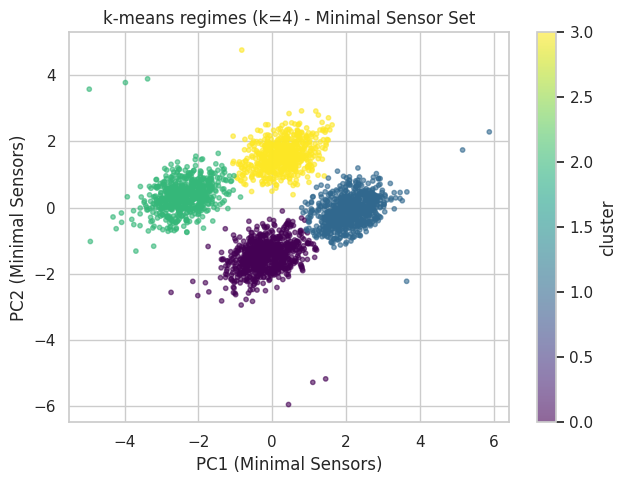

In [30]:
from sklearn.decomposition import PCA

# Perform PCA on the minimal sensor set (X_min) to reduce to 2 dimensions for visualization
pca_min = PCA(n_components=2, random_state=0).fit_transform(X_min)

# Create the scatter plot
fig, ax = plt.subplots(figsize=(6.5, 5))
sc = ax.scatter(pca_min[:, 0], pca_min[:, 1], c=df_min_sensors['cluster_min'], cmap='viridis', s=10, alpha=0.6)

ax.set_xlabel('PC1 (Minimal Sensors)');
ax.set_ylabel('PC2 (Minimal Sensors)');
ax.set_title(f'k-means regimes (k={best_k}) - Minimal Sensor Set')
plt.colorbar(sc, label='cluster');
plt.tight_layout();
plt.show()

The minimal sensor set! Based on PCA loadings, the 5 most informative sensors are pier_tilt_urad, accel_rms_mg, humidity_pct, traffic_count, and natural_freq_hz.

When using these 5 sensors:

Clustering performance (ARI) with the minimal sensor set is 0.959, which is slightly lower than the 0.986 achieved with the original full sensor set. This indicates a minor reduction in the ability to recover the true operating regimes.
GMM anomaly detection performance shows a more significant drop:
Precision decreased from 0.872 (full set) to 0.651 (minimal set).
Recall decreased from 1.0 (full set) to 0.747 (minimal set).
The number of flagged anomalies remained the same at 86.
In conclusion, while the minimal sensor set still provides decent clustering performance, there's a notable reduction in the precision and recall of anomaly detection compared to the full sensor set. This trade-off between instrumentation cost and performance would need careful consideration for a real-world deployment.

## 📘 Summary

Starting from an **unlabelled** 12-sensor bridge feed, the Day 9 unsupervised toolkit turned raw data into action: **scaling** levelled the channels, **PCA** compressed them to a few health indices, **elbow + silhouette** chose the number of regimes, **k-means / hierarchical / GMM** discovered and confirmed them, and **novelty detection** surfaced the readings an engineer should inspect — all without a single labelled example.

**The unsupervised mindset:** when nobody can label millions of rows, let the data reveal its own structure — then bring engineering judgement to name the regimes and act on the anomalies.